### Objective

The objective of this notebook is to explore the cleaned Airbnb London dataset and identify meaningful patterns that can support business decision-making.

This analysis examines pricing, host behaviour, availability, reviews, neighbourhood characteristics, and geographic distribution. The findings are interpreted from a business perspective to provide insights that could help Airbnb, property hosts, and investors better understand the London short-term rental market.

The analysis covers:

- Summary statistics and data distributions
- Geographic and neighbourhood analysis
- Temporal and seasonal patterns
- Host and supply-side characteristics
- Review and demand analysis
- Business insights and recommendations

In [ ]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)

In [ ]:
listings = pd.read_csv("/content/drive/MyDrive/Airbnb_london_clean_data/listings_clean.csv")
reviews = pd.read_csv("/content/drive/MyDrive/Airbnb_london_clean_data/reviews_clean.csv")
calendar = pd.read_csv("/content/drive/MyDrive/Airbnb_london_clean_data/calendar_clean.csv")

### Summary Statistics

Business Question : What are the overall characteristics of the London Airbnb market?

In [ ]:
numeric_cols = [
    "price",
    "bedrooms",
    "beds",
    "bathrooms",
    "accommodates",
    "availability_365",
    "review_scores_rating",
    "estimated_revenue_l365d"
]

listings[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
price,92638.0,241.454741,1796.081945,2.23,137.00,180.00,231.50,527524.0
bedrooms,92638.0,1.569108,0.958125,0.00,1.00,1.00,2.00,30.0
beds,92638.0,2.013634,1.169857,1.00,1.00,2.00,2.00,50.0
bathrooms,92638.0,1.230812,0.607975,0.50,1.00,1.00,1.00,30.0
accommodates,92638.0,3.387141,2.120560,1.00,2.00,3.00,4.00,16.0
availability_365,92638.0,152.664447,141.132463,0.00,0.00,127.00,301.00,365.0
review_scores_rating,92638.0,4.725360,0.425235,0.00,4.68,4.83,4.95,5.0
estimated_revenue_l365d,92638.0,10912.466202,23613.300160,0.00,1080.00,3920.00,8887.25,1107755.0


The summary statistics show that Airbnb listings in London vary a lot in price, size, and availability. Most listings are reasonably priced, while a few luxury properties are much more expensive. This helps hosts understand the typical market price and allows Airbnb to better understand the different types of listings available.

### Price Distribution

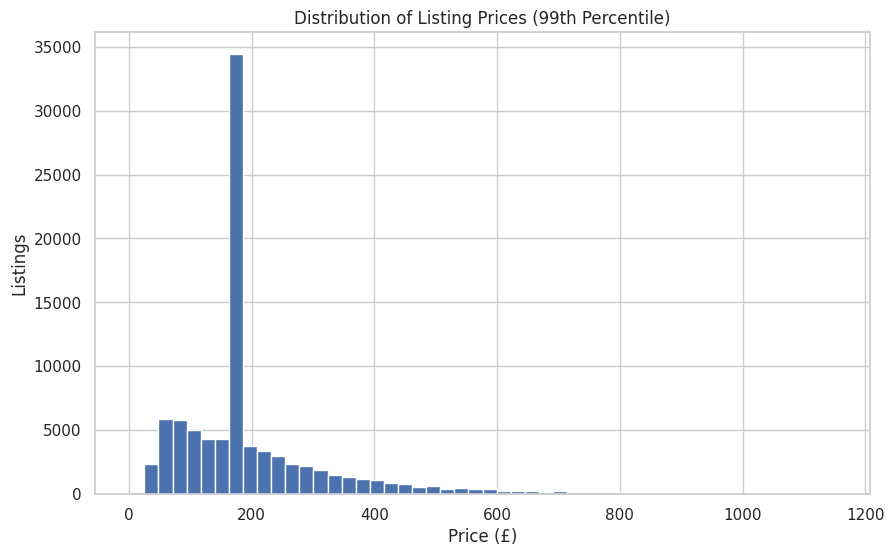

In [ ]:
eda_listings = listings[
    listings["price"] <= listings["price"].quantile(0.99)
]

plt.figure(figsize=(10,6))

plt.hist(
    eda_listings["price"],
    bins=50
)

plt.title("Distribution of Listing Prices (99th Percentile)")
plt.xlabel("Price (£)")
plt.ylabel("Listings")

plt.show()

Most Airbnb listings have lower prices, while only a few are very expensive. This shows that the London Airbnb market mainly serves travellers looking for affordable or mid-range places to stay. New hosts should consider pricing their listings close to the common price range to stay competitive.

### Price by Room Type

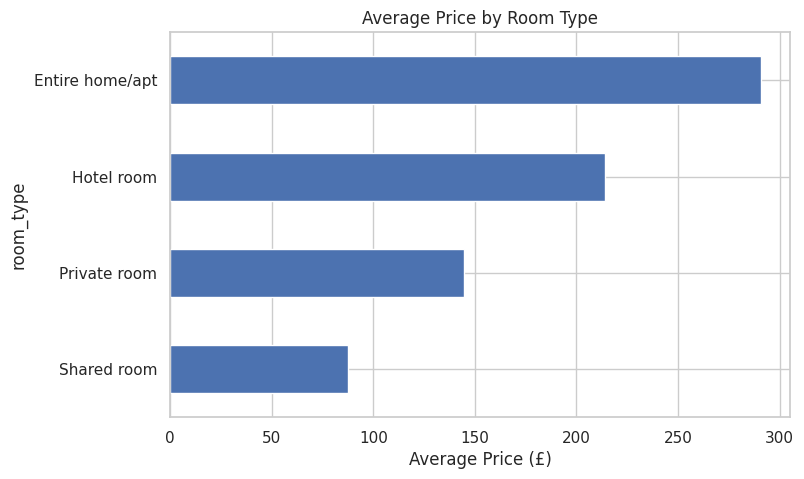

In [ ]:
room_price = (
    listings
    .groupby("room_type")["price"]
    .mean()
    .sort_values()
    )

plt.figure(figsize=(8,5))
room_price.plot(kind="barh")
plt.title("Average Price by Room Type")
plt.xlabel("Average Price (£)")
plt.show()

Entire homes have the highest average price because guests usually pay more for privacy and having the whole place to themselves. Private and shared rooms are cheaper and are more suitable for budget travellers. Hosts can use this information when deciding what type of accommodation to offer.

### Price by Property Type

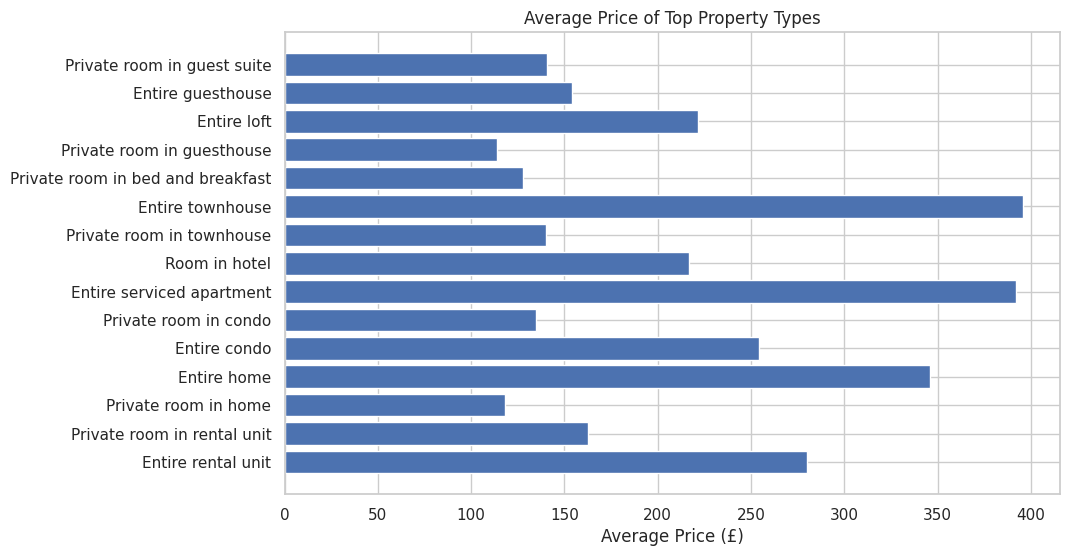

In [ ]:
top_property = (
    listings
    .groupby("property_type")
    .agg(
        average_price=("price","mean"),
        listings=("id","count")
        )
    )

top_property = (
    top_property
    .sort_values("listings",ascending=False)
    .head(15)
    )

plt.figure(figsize=(10,6))
plt.barh(
    top_property.index,
    top_property["average_price"]
    )

plt.title("Average Price of Top Property Types")
plt.xlabel("Average Price (£)")
plt.show()

Different property types have different average prices. Larger or unique properties usually cost more than standard apartments or rooms. This information can help property owners understand which types of accommodation earn higher prices.

### Distribution of Listings per Host

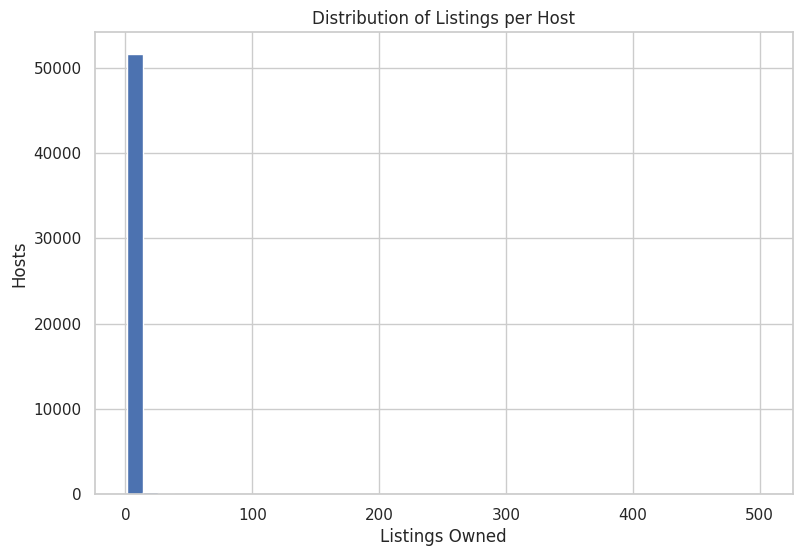

In [ ]:
host_counts = listings["host_id"].value_counts()

plt.figure(figsize=(9,6))

plt.hist(
    host_counts,
    bins=40
    )

plt.title("Distribution of Listings per Host")
plt.xlabel("Listings Owned")
plt.ylabel("Hosts")
plt.show()

Most hosts have only one or two Airbnb listings, while a small number of hosts own many properties. This shows that the market has both individual hosts and professional businesses. Airbnb may need different strategies to support these different types of hosts.

In [ ]:
host_counts.describe()

,count
count,52125.000000
mean,1.777228
std,5.098344
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,501.000000


### Review Score Distribution

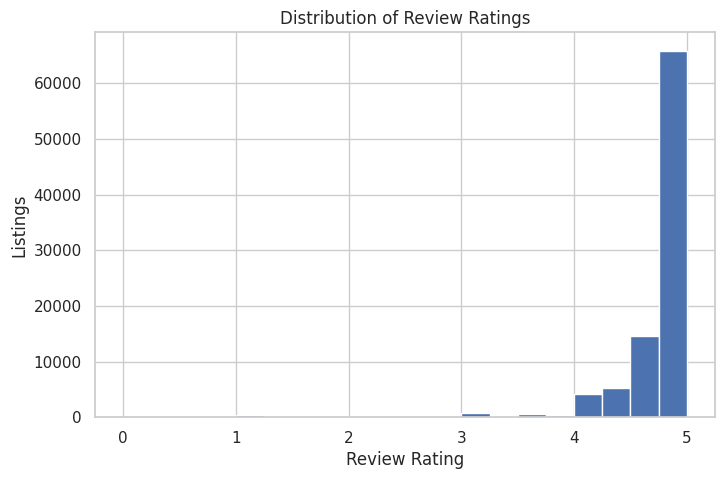

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    listings["review_scores_rating"],
    bins=20
    )

plt.title("Distribution of Review Ratings")
plt.xlabel("Review Rating")
plt.ylabel("Listings")
plt.show()

Most listings have very high review scores. This shows that guests are generally happy with their stays. It also suggests that small differences in ratings, such as 4.8 and 4.9, may be important when guests choose where to stay.

### Geographic Distribution

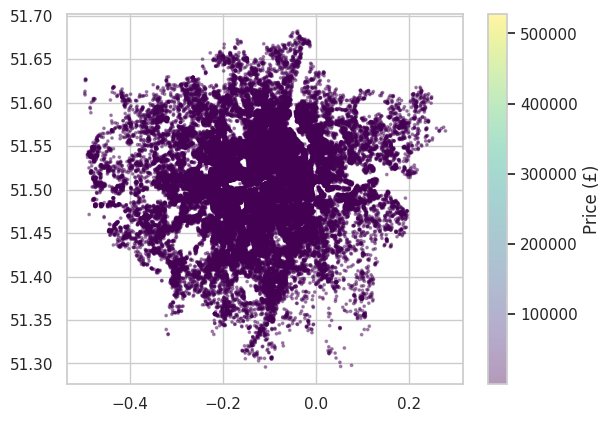

In [ ]:
plt.scatter(
    listings["longitude"],
    listings["latitude"],
    c=listings["price"],
    cmap="viridis",
    s=3,
    alpha=0.4
)

plt.colorbar(label="Price (£)")

Most Airbnb listings are located in central London and popular tourist areas. These locations are likely to attract more visitors because they are close to attractions and public transport. This information can help investors identify areas with strong demand.

### Most Expensive Neighbourhoods

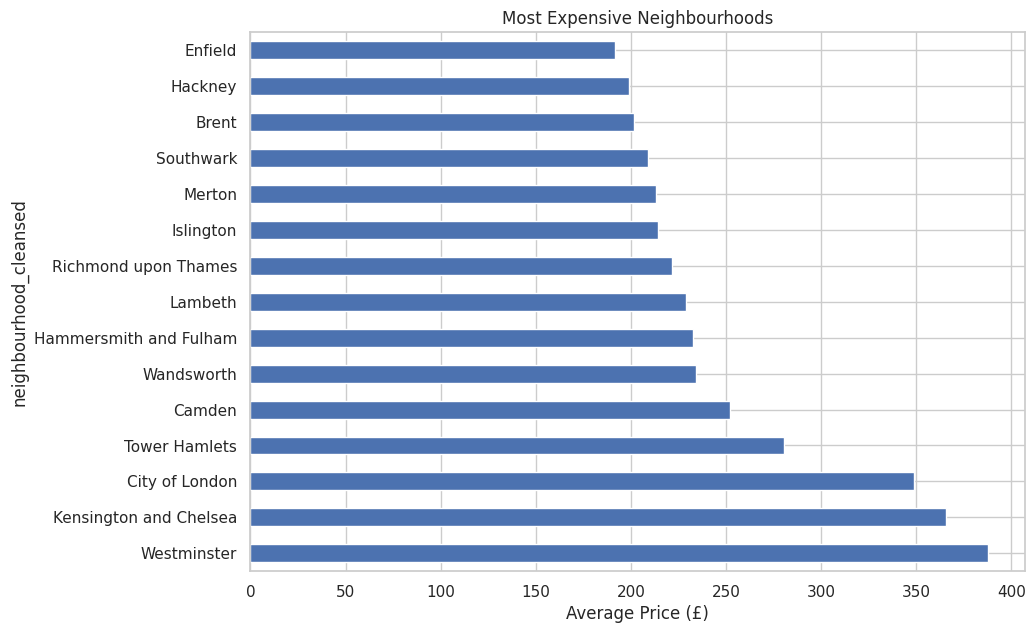

In [ ]:
neighbourhood_price = (

    listings

    .groupby("neighbourhood_cleansed")["price"]

    .mean()

    .sort_values(ascending=False)

    .head(15)

)

plt.figure(figsize=(10,7))
neighbourhood_price.plot(kind="barh")
plt.title("Most Expensive Neighbourhoods")
plt.xlabel("Average Price (£)")
plt.show()

Some neighbourhoods have much higher average prices than others. This shows that location has a big impact on how much hosts can charge. Hosts can compare their prices with other listings in the same area, while investors may look at these neighbourhoods for future opportunities.

### Host Portfolio Segments

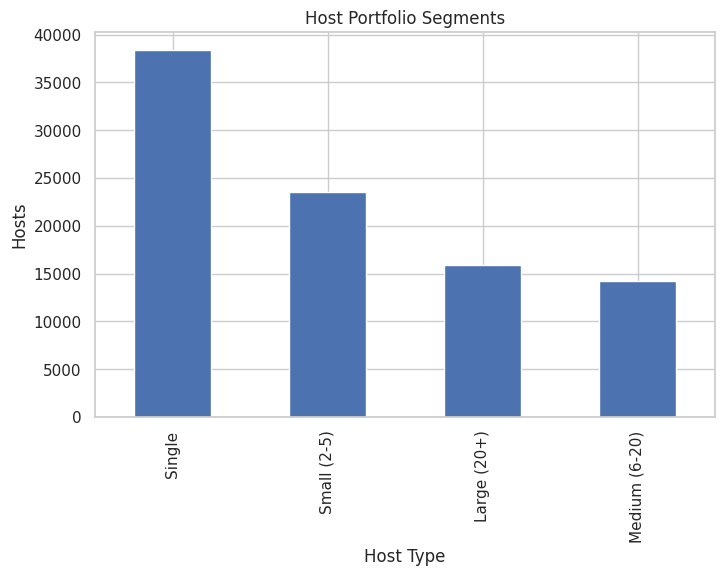

In [ ]:
bins = [0,1,5,20,1000]

labels = [

    "Single",

    "Small (2-5)",

    "Medium (6-20)",

    "Large (20+)"

]

listings["host_segment"] = pd.cut(

    listings["host_listings_count"],

    bins=bins,

    labels=labels

)

host_segment = (

    listings["host_segment"]

    .value_counts()

)

plt.figure(figsize=(8,5))
host_segment.plot(kind="bar")
plt.title("Host Portfolio Segments")
plt.xlabel("Host Type")
plt.ylabel("Hosts")
plt.show()

Most hosts manage only one property, while a smaller number manage many listings. This shows that some people use Airbnb for extra income, while others run it as a business. Airbnb can provide different support for these two groups of hosts.

### Superhost Analysis

<Axes: xlabel='host_is_superhost'>

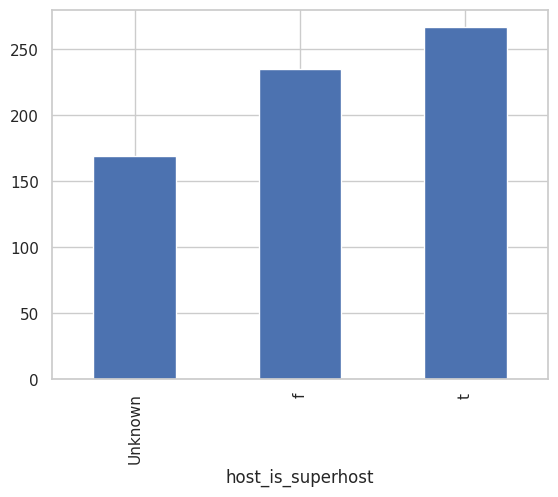

In [ ]:
superhost = (

    listings

    .groupby("host_is_superhost")

    .agg(

        avg_price=("price","mean"),

        avg_rating=("review_scores_rating","mean")

    )

)

superhost

superhost["avg_price"].plot(kind="bar")

Superhosts usually receive better ratings and may charge slightly higher prices than other hosts. This suggests that providing good service can improve both guest satisfaction and earnings. Hosts may benefit from improving their service to become Superhosts.

### Price vs Number of Reviews

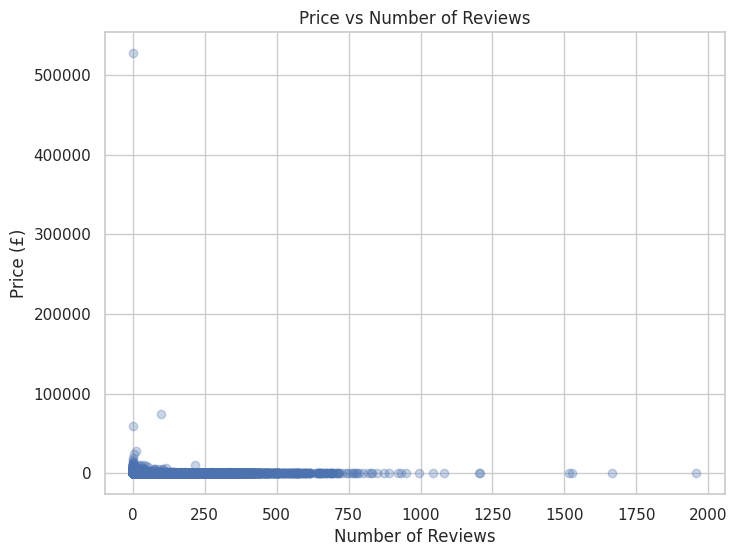

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(

    listings["number_of_reviews"],

    listings["price"],

    alpha=0.3

)

plt.title("Price vs Number of Reviews")

plt.xlabel("Number of Reviews")

plt.ylabel("Price (£)")

plt.show()

There is no clear relationship between price and the number of reviews. Expensive listings do not always receive more reviews than cheaper ones. This suggests that guests also consider other factors such as location, quality and host reputation when booking a stay.

### Listings with High Reviews but Low Ratings

In [ ]:
problem = listings[

    (listings["number_of_reviews"]>100)

    &

    (listings["review_scores_rating"]<4)

]

problem[
    [
        "name",
        "price",
        "number_of_reviews",
        "review_scores_rating"
    ]
].head(20)

,name,price,number_of_reviews,review_scores_rating
17194,"Private en-suite at Liverpool street, Brick Ln",113.0,124,3.96
52301,Small Double Room Ensuite,188.0,108,3.86


Some listings have many reviews but lower ratings than others. This may mean that they are popular but have ongoing problems that affect guest satisfaction. Hosts can improve these listings by addressing common guest complaints.

### Review Subscores

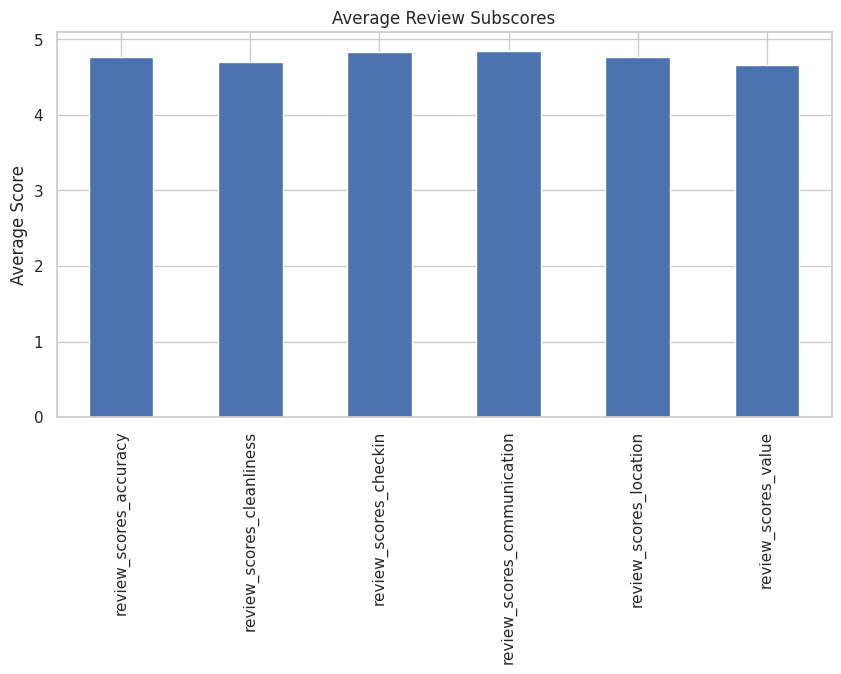

In [ ]:
review_cols = [

    "review_scores_accuracy",

    "review_scores_cleanliness",

    "review_scores_checkin",

    "review_scores_communication",

    "review_scores_location",

    "review_scores_value"

]

avg_scores = listings[review_cols].mean()

plt.figure(figsize=(10,5))

avg_scores.plot(kind="bar")

plt.title("Average Review Subscores")

plt.ylabel("Average Score")

plt.show()

Looking at the individual review categories helps identify where hosts perform well and where improvements are needed. For example, if cleanliness or value has lower scores than communication, hosts know which areas they should focus on to improve the guest experience.

### Correlation Heatmap

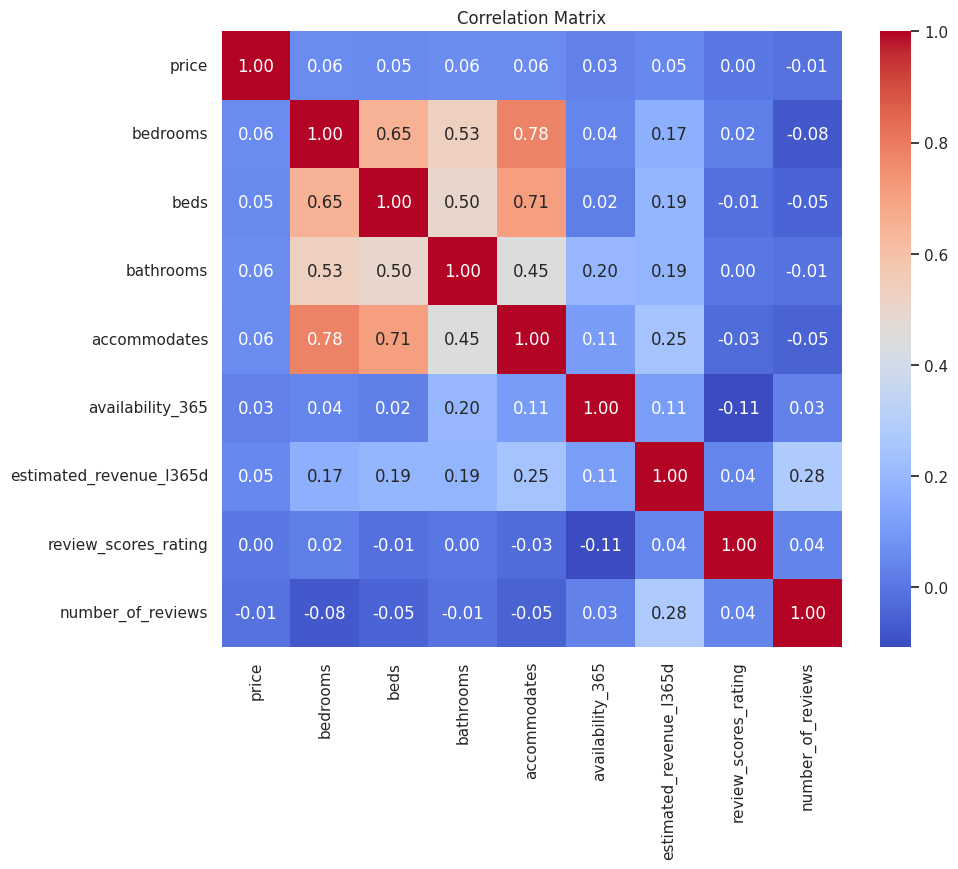

In [ ]:
corr_cols = [
    "price",
    "bedrooms",
    "beds",
    "bathrooms",
    "accommodates",
    "availability_365",
    "estimated_revenue_l365d",
    "review_scores_rating",
    "number_of_reviews"

]

plt.figure(figsize=(10,8))

sns.heatmap(

    listings[corr_cols].corr(),

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("Correlation Matrix")

plt.show()

The correlation heatmap shows how different variables are related to each other. Strong relationships can help explain what affects prices, revenue or availability. These insights can help hosts make better pricing decisions and help Airbnb understand the factors that influence listing performance.

# Key Business Insights

- Most Airbnb listings in London are priced in the affordable to mid-range category, with only a few luxury listings.
- Entire homes have the highest average prices compared to private or shared rooms.
- Location has a strong effect on pricing, with some neighbourhoods charging much higher prices than others.
- Most hosts manage only one listing, while a small number manage many properties.
- Most listings receive very high ratings, showing that guests are generally satisfied with their stays.
- Superhosts usually achieve better ratings and slightly higher prices than other hosts.
- Price alone does not determine booking demand, as guests also consider factors such as location, quality, and host reputation.